第    1 轮训练 MSE: 298.5316
第   10 轮训练 MSE: 4.0306
第  100 轮训练 MSE: 4.0305
模型: SGDRegressor(eta0=0.0001, learning_rate='constant', max_iter=1, penalty=None,
             random_state=42, tol=None) 标准化器: StandardScaler() MSE历史记录: [298.53161045440027, 43.97920348836597, 9.46301811805003, 4.774169944032101, 4.134113611051556, 4.045611577282789, 4.032961692181845, 4.031004660220578, 4.03064981782502, 4.030568649531643, 4.030545440479253, 4.030537788783721, 4.030535088368512, 4.030534108321693, 4.030533748789101, 4.030533616356071, 4.030533567498758, 4.030533549463, 4.030533542803173, 4.030533540343597, 4.03053353943513, 4.030533539099546, 4.030533538975571, 4.030533538929766, 4.030533538912838, 4.030533538906586, 4.030533538904279, 4.030533538903421, 4.030533538903107, 4.030533538902992, 4.030533538902947, 4.03053353890293, 4.030533538902923, 4.030533538902922, 4.030533538902922, 4.0305335389029215, 4.0305335389029215, 4.0305335389029215, 4.0305335389029215, 4.0305335389029215, 4.0305335389029

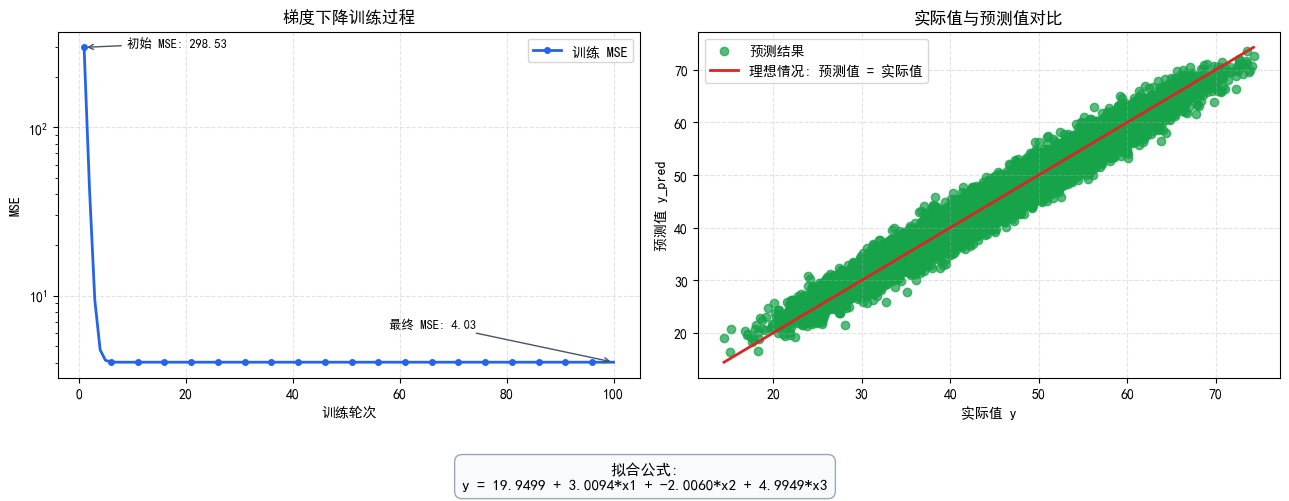

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

DATA_FILE = "data2.csv"
EPOCHS = 100
LEARNING_RATE = 0.0001
RANDOM_SEED = 42

def configure_chinese_font():
    """配置中文字体，避免图表中的中文乱码。"""
    rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
    plt.rcParams["axes.unicode_minus"] = False

def load_training_data(file_path):
    """读取 CSV 文件，并拆分出特征 X 和目标 y。"""
    data = np.genfromtxt(file_path, delimiter=",", names=True)

    # X 是特征矩阵，包含 x1、x2、x3 三个特征。
    features = np.column_stack((data["x1"], data["x2"], data["x3"]))

    # y 是目标值，也就是要预测的结果。
    target = data["y"]

    return features, target

def convert_weights_to_original_scale(model, scaler):
    """
    SGDRegressor 在标准化后的特征上训练。

    为了得到原始公式：
        y = b + w1*x1 + w2*x2 + w3*x3

    需要把标准化空间里的权重转换回原始数据空间。
    """
    scaled_weights = model.coef_
    scaled_bias = model.intercept_[0]

    original_weights = scaled_weights / scaler.scale_
    original_bias = scaled_bias - np.sum(
        scaled_weights * scaler.mean_ / scaler.scale_
    )

    return original_weights, original_bias

def train_with_gradient_descent(features, target):
    """使用 SGDRegressor 通过梯度下降不断优化 w 和 b。"""
    scaler = StandardScaler()

    # 梯度下降对特征尺度比较敏感，所以先把 x1、x2、x3 标准化。
    scaled_features = scaler.fit_transform(features)

    # 使用随机梯度下降回归器训练模型
    # loss="squared_error", 表示使用均方误差作为损失函数
    model = SGDRegressor(
        loss="squared_error",
        penalty=None,
        learning_rate="constant",
        eta0=LEARNING_RATE,
        max_iter=1,
        tol=None,
        random_state=RANDOM_SEED,
    )

    mse_history = []

    for epoch in range(EPOCHS):
        # partial_fit 表示继续训练一轮，而不是每次从头开始训练。
        model.partial_fit(scaled_features, target)

        predicted = model.predict(scaled_features)
        mse = mean_squared_error(target, predicted)
        mse_history.append(mse)

        if epoch in [0, 9, 99, 499, 999, EPOCHS - 1]:
            print(f"第 {epoch + 1:>4} 轮训练 MSE: {mse:.4f}")

    # print('模型:',model,'标准化器:',scaler,'MSE历史记录:',mse_history)

    return model, scaler, mse_history

def plot_training_result(target, predicted, mse_history, weights, bias):
    """展示训练过程和最终拟合效果。"""
    fig = plt.figure(figsize=(13, 5))

    plt.subplot(1, 2, 1)
    epochs = np.arange(1, len(mse_history) + 1)
    plt.plot(
        epochs,
        mse_history,
        color="#2563eb",
        linewidth=2,
        marker="o",
        markevery=max(1, len(mse_history) // 20),
        markersize=4,
        label="训练 MSE",
    )
    plt.title("梯度下降训练过程")
    plt.xlabel("训练轮次")
    plt.ylabel("MSE")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()

    plt.annotate(
        f"初始 MSE: {mse_history[0]:.2f}",
        xy=(epochs[0], mse_history[0]),
        xytext=(epochs[0] + len(epochs) * 0.08, mse_history[0]),
        arrowprops={"arrowstyle": "->", "color": "#475569"},
        fontsize=9,
    )
    plt.annotate(
        f"最终 MSE: {mse_history[-1]:.2f}",
        xy=(epochs[-1], mse_history[-1]),
        xytext=(epochs[-1] * 0.58, mse_history[-1] * 1.6),
        arrowprops={"arrowstyle": "->", "color": "#475569"},
        fontsize=9,
    )

    plt.subplot(1, 2, 2)
    plt.scatter(target, predicted, color="#16a34a", alpha=0.72, label="预测结果")

    min_value = min(target.min(), predicted.min())
    max_value = max(target.max(), predicted.max())
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        color="#dc2626",
        linewidth=2,
        label="理想情况: 预测值 = 实际值",
    )

    plt.title("实际值与预测值对比")
    plt.xlabel("实际值 y")
    plt.ylabel("预测值 y_pred")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()

    formula = (
        "拟合公式:\n"
        f"y = {bias:.4f}"
        f" + {weights[0]:.4f}*x1"
        f" + {weights[1]:.4f}*x2"
        f" + {weights[2]:.4f}*x3"
    )

    plt.figtext(
        0.5,
        0.01,
        formula,
        ha="center",
        fontsize=11,
        bbox={
            "boxstyle": "round,pad=0.5",
            "facecolor": "#f8fafc",
            "edgecolor": "#94a3b8",
            "alpha": 0.95,
        },
    )

    plt.tight_layout(rect=(0, 0.12, 1, 1))

    plt.show()


def main():
    configure_chinese_font()

    # 获取特征和目标变量
    features, target = load_training_data(DATA_FILE)
    # 训练模型，返回模型、标准化器和 MSE 历史记录
    model, scaler, mse_history = train_with_gradient_descent(features, target)

    predicted = model.predict(scaler.transform(features))
    mae = mean_absolute_error(target, predicted)
    mse = mean_squared_error(target, predicted)

    weights, bias = convert_weights_to_original_scale(model, scaler)

    print("\n梯度下降拟合结果：")
    print(f"b  = {bias:.4f}")
    print(f"w1 = {weights[0]:.4f}")
    print(f"w2 = {weights[1]:.4f}")
    print(f"w3 = {weights[2]:.4f}")
    print(f"MAE = {mae:.4f}")
    print(f"MSE = {mse:.4f}")

    print("\n真实生成数据时使用的参数大约是：")
    print("b = 20, w1 = 3, w2 = -2, w3 = 5")

    plot_training_result(target, predicted, mse_history, weights, bias)


if __name__ == "__main__":
    main()


In [31]:
# 展示训练过程和最终拟合效果
def plot_training_result(target, predicted, mse_history, weights, bias):
    """展示训练过程和最终拟合效果。"""
    fig = plt.figure(figsize=(13, 5))

    plt.subplot(1, 2, 1)
    epochs = np.arange(1, len(mse_history) + 1)
    plt.plot(
        epochs,
        mse_history,
        color="#2563eb",
        linewidth=2,
        marker="o",
        markevery=max(1, len(mse_history) // 20),
        markersize=4,
        label="训练 MSE",
    )
    plt.title("梯度下降训练过程")
    plt.xlabel("训练轮次")
    plt.ylabel("MSE")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()

    plt.annotate(
        f"初始 MSE: {mse_history[0]:.2f}",
        xy=(epochs[0], mse_history[0]),
        xytext=(epochs[0] + len(epochs) * 0.08, mse_history[0]),
        arrowprops={"arrowstyle": "->", "color": "#475569"},
        fontsize=9,
    )
    plt.annotate(
        f"最终 MSE: {mse_history[-1]:.2f}",
        xy=(epochs[-1], mse_history[-1]),
        xytext=(epochs[-1] * 0.58, mse_history[-1] * 1.6),
        arrowprops={"arrowstyle": "->", "color": "#475569"},
        fontsize=9,
    )

    plt.subplot(1, 2, 2)
    plt.scatter(target, predicted, color="#16a34a", alpha=0.72, label="预测结果")

    min_value = min(target.min(), predicted.min())
    max_value = max(target.max(), predicted.max())
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        color="#dc2626",
        linewidth=2,
        label="理想情况: 预测值 = 实际值",
    )

    plt.title("实际值与预测值对比")
    plt.xlabel("实际值 y")
    plt.ylabel("预测值 y_pred")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()

    formula = (
        "拟合公式:\n"
        f"y = {bias:.4f}"
        f" + {weights[0]:.4f}*x1"
        f" + {weights[1]:.4f}*x2"
        f" + {weights[2]:.4f}*x3"
    )

    plt.figtext(
        0.5,
        0.01,
        formula,
        ha="center",
        fontsize=11,
        bbox={
            "boxstyle": "round,pad=0.5",
            "facecolor": "#f8fafc",
            "edgecolor": "#94a3b8",
            "alpha": 0.95,
        },
    )

    plt.tight_layout(rect=(0, 0.12, 1, 1))

    plt.show()

In [ ]:
def plot_convex_loss_surface(features, target, weights, bias, weight_name):
    """
    绘制线性回归 MSE 损失函数的凸函数图像。

    当前模型有 4 个参数：
        y = b + w1*x1 + w2*x2 + w3*x3

    完整的 MSE 损失函数同时受 b、w1、w2、w3 影响，
    这是 4 个参数维度 + 1 个损失值维度，无法直接画成普通 3D 图。

    为了让图像可视化，这里通过 weight_name 指定观察哪个权重：
        weight_name="w1" 表示观察 w1 和 b
        weight_name="w2" 表示观察 w2 和 b
        weight_name="w3" 表示观察 w3 和 b

    其他权重固定为训练后的值。对于线性回归的 MSE，
    这个二维参数切片通常是一个凸的“碗形”。
    """
    weight_index_map = {"w1": 0, "w2": 1, "w3": 2}

    if weight_name not in weight_index_map:
        raise ValueError('weight_name 只能是 "w1"、"w2" 或 "w3"。')

    weight_index = weight_index_map[weight_name]
    selected_weight = weights[weight_index]

    weight_values = np.linspace(selected_weight - 2, selected_weight + 2, 80)
    b_values = np.linspace(bias - 8, bias + 8, 80)
    weight_grid, b_grid = np.meshgrid(weight_values, b_values)

    mse_grid = np.zeros_like(weight_grid)

    for row in range(weight_grid.shape[0]):
        for col in range(weight_grid.shape[1]):
            current_weights = weights.copy()
            current_weights[weight_index] = weight_grid[row, col]
            current_b = b_grid[row, col]

            predicted = current_b + features @ current_weights
            mse_grid[row, col] = mean_squared_error(target, predicted)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    surface = ax.plot_surface(
        weight_grid,
        b_grid,
        mse_grid,
        cmap="viridis",
        alpha=0.88,
        linewidth=0,
    )

    ax.scatter(
        selected_weight,
        bias,
        mean_squared_error(target, bias + features @ weights),
        color="#dc2626",
        s=80,
        label="当前拟合参数",
    )

    fixed_weights = [name for name in weight_index_map if name != weight_name]
    ax.set_title(
        f"MSE 损失函数凸曲面：固定 {fixed_weights[0]}、{fixed_weights[1]}，"
        f"观察 {weight_name} 和 b"
    )
    ax.set_xlabel(weight_name)
    ax.set_ylabel("b")
    ax.set_zlabel("MSE")
    ax.legend()
    fig.colorbar(surface, shrink=0.58, aspect=12, label="MSE")

    plt.tight_layout()
    plt.show()

第    1 轮训练 MSE: 298.5316
第   10 轮训练 MSE: 4.0306
第  100 轮训练 MSE: 4.0305

梯度下降拟合结果：
b  = 19.9499
w1 = 3.0094
w2 = -2.0060
w3 = 4.9949
MAE = 1.5990
MSE = 4.0305

真实生成数据时使用的参数大约是：
b = 20, w1 = 3, w2 = -2, w3 = 5


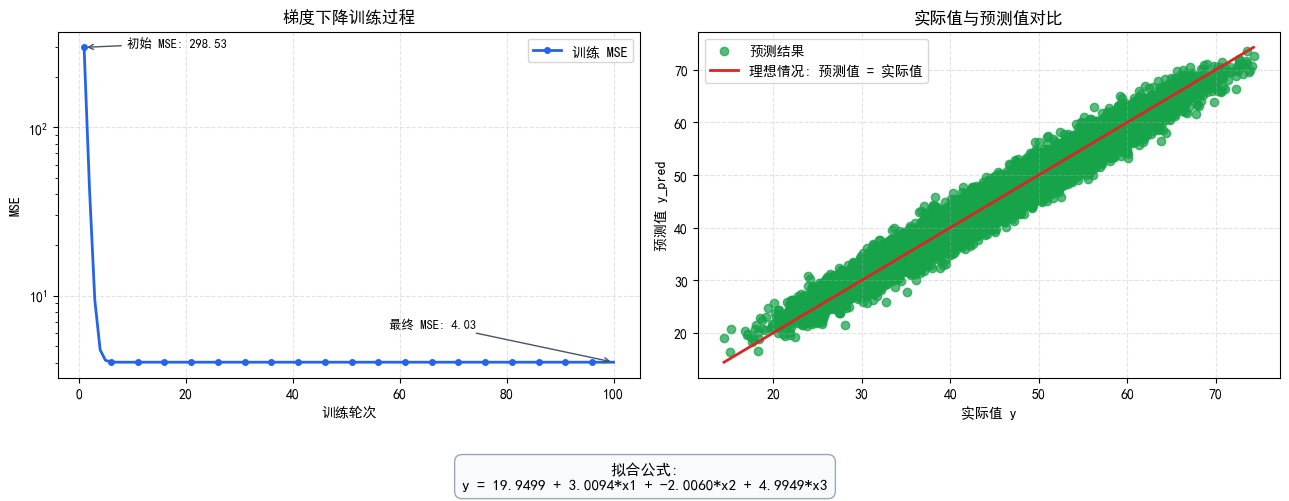

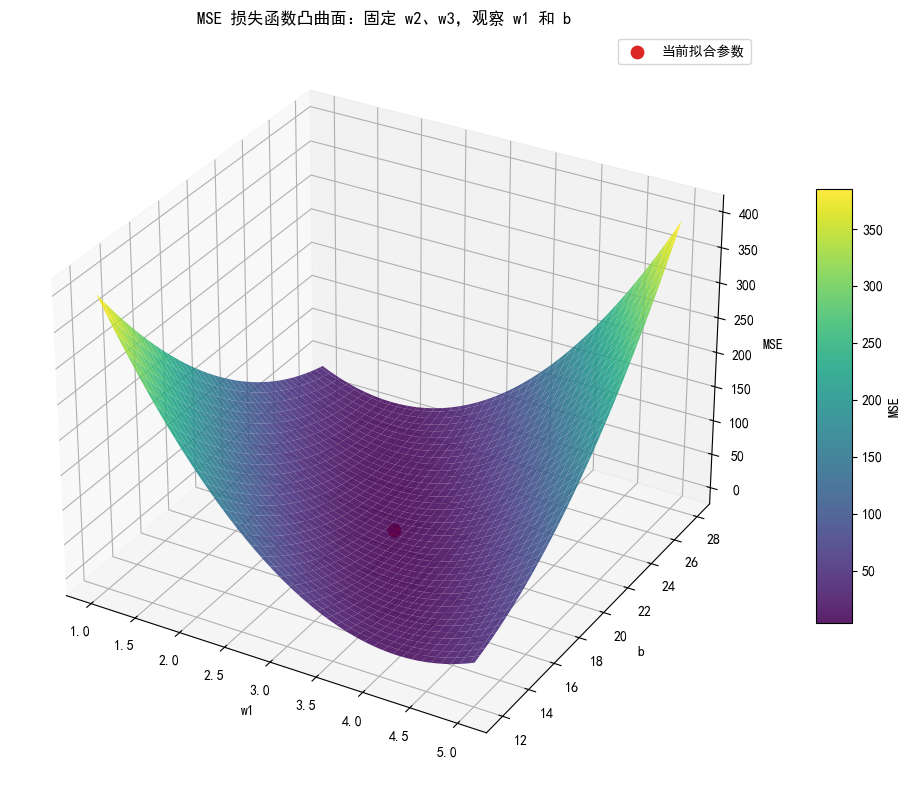

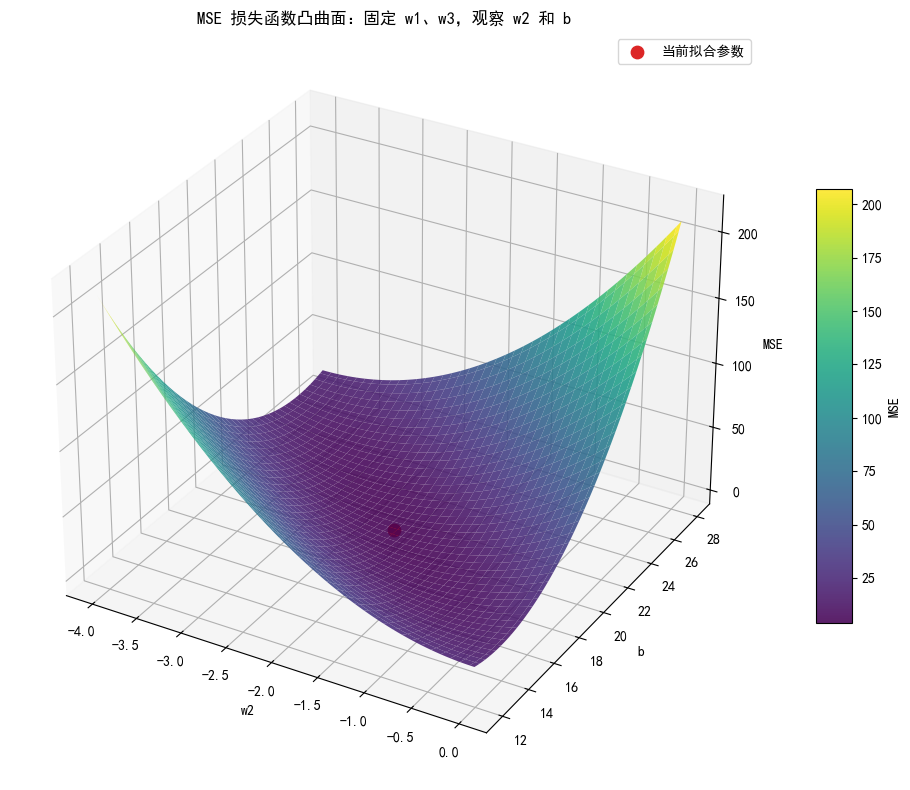

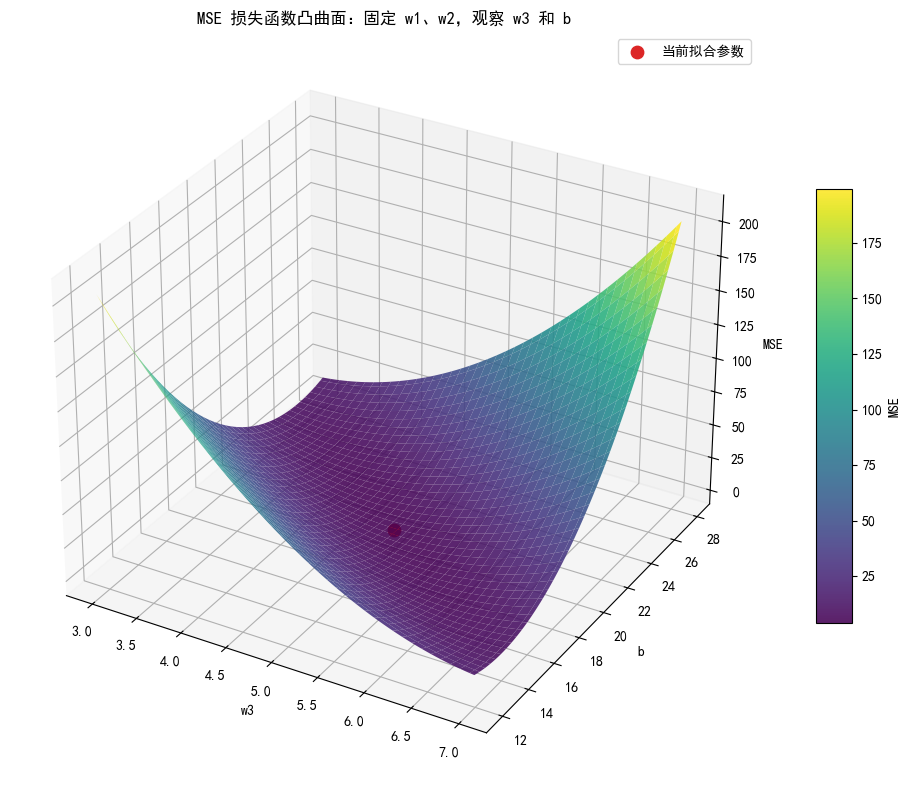

In [37]:
# 梯度下降法

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler


DATA_FILE = "data2.csv" #数据文件路径
EPOCHS = 100            # 训练轮数
LEARNING_RATE = 0.0001  # 学习率，步长
RANDOM_SEED = 42        # 随机种子，用于可重复性

"""配置中文字体，避免图表中的中文乱码。"""
rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

data = np.genfromtxt(DATA_FILE, delimiter=",", names=True)
# 特征列
features = np.column_stack((data["x1"], data["x2"], data["x3"]))
# 目标值
target = data["y"]

# 数据预处理,标准化、归一化
scaler = StandardScaler()
# 数据标准化后的特征列
scaled_features = scaler.fit_transform(features)

# 设置模型参数
# loss="squared_error", 表示使用均方误差作为损失函数
model = SGDRegressor(
    loss="squared_error",
    penalty=None,learning_rate="constant",
    eta0=LEARNING_RATE,max_iter=1,
    tol=None,random_state=RANDOM_SEED,
)
mse_history = []

# 根据轮次训练模型
for epoch in range(EPOCHS):
    # partial_fit 表示继续训练一轮，而不是每次从头开始训练。
    model.partial_fit(scaled_features, target)

    # 使用当前模型参数预测所有数据的目标值
    predicted = model.predict(scaled_features)
    # 计算当前模型参数下的均方误差
    mse = mean_squared_error(target, predicted)
    mse_history.append(mse)

    if epoch in [0, 9, 99, 499, 999, EPOCHS - 1]:
        print(f"第 {epoch + 1:>4} 轮训练 MSE: {mse:.4f}")

# 训练完成之后最后一次预测，计算最终的均方误差和平均绝对误差
predicted = model.predict(scaler.transform(features))
mae = mean_absolute_error(target, predicted)
mse = mean_squared_error(target, predicted)

# 得到原始公式，把标准化空间里的权重转换回原始数据空间
# 获取权重和偏置项
scaled_weights = model.coef_
scaled_bias = model.intercept_[0]

weights = scaled_weights / scaler.scale_
bias = scaled_bias - np.sum(
    scaled_weights * scaler.mean_ / scaler.scale_
)

print("\n梯度下降拟合结果：")
print(f"b  = {bias:.4f}")
print(f"w1 = {weights[0]:.4f}")
print(f"w2 = {weights[1]:.4f}")
print(f"w3 = {weights[2]:.4f}")
print(f"MAE = {mae:.4f}")
print(f"MSE = {mse:.4f}")

print("\n真实生成数据时使用的参数大约是：")
print("b = 20, w1 = 3, w2 = -2, w3 = 5")


plot_training_result(target, predicted, mse_history, weights, bias)
plot_convex_loss_surface(features, target, weights, bias, "w1")
plot_convex_loss_surface(features, target, weights, bias, "w2")
plot_convex_loss_surface(features, target, weights, bias, "w3")
